<a href="https://colab.research.google.com/github/eniompw/microgpt/blob/dev/microgpt_fast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MicroGPT — PyTorch (Colab T4 GPU)

The most atomic way to train and run inference for a GPT in pure PyTorch.
Based on [@karpathy](https://github.com/karpathy)'s microgpt.

> **Runtime:** Go to **Runtime → Change runtime type → T4 GPU** before running.

## 1. GPU Setup and Library Imports

In [1]:
import os, random, json
import torch
import torch.nn.functional as F

random.seed(42); torch.manual_seed(42)  # reproducibility
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"device: {device}" + (f" | {torch.cuda.get_device_name(0)}" if device.type == 'cuda' else ''))


device: cuda | Tesla T4


## 2. Dataset Download and Preparation

In [2]:
if not os.path.exists('input.txt'):
    import warnings, pandas as pd
    warnings.filterwarnings('ignore', category=UserWarning, module='huggingface_hub')
    df = pd.read_parquet("hf://datasets/karpathy/tinystories-gpt4-clean/tinystories_gpt4_clean.parquet")
    with open('input.txt', 'w') as f:
        for s in df['text'].iloc[20000:25000]:  # 5000 stories
            f.write(json.dumps(s) + '\n')

docs = [json.loads(l) for l in open('input.txt') if l.strip()]
random.shuffle(docs)
print(f"docs: {len(docs)}, sample: {docs[0][:80]}...")


docs: 5000, sample: Ben and Lily were playing in the farm with their new friend, Mira the mule. Mira...


## 3. Tokenizer Setup

In [3]:
# Character-level vocab — 74 printable ASCII chars + BOS (beginning-of-story) token
uchars = sorted('\n !"$\',-.' + '0123456789:;?' + 'ABCDEFGHIJKLMNOPQRSTUVWXYZ' + 'abcdefghijklmnopqrstuvwxyz')
BOS = len(uchars); vocab_size = BOS + 1

# Encode / decode helpers
stoi = {c: i for i, c in enumerate(uchars)}
encode = lambda s: [stoi[c] for c in s]
decode = lambda ids: ''.join(uchars[i] for i in ids)
print(f"vocab: {vocab_size}, BOS: {BOS}")


vocab: 75, BOS: 74


## 4. Model Hyperparameters and Parameter Initialization

In [4]:
import math

# ── Hyperparameters ──────────────────────────────────────────────────────────
n_layer    = 6       # transformer depth
n_embd     = 256     # embedding dim
block_size = 256     # context window
n_head     = 8       # attention heads
head_dim   = n_embd // n_head
batch_size = 64      # sequences per gradient step

# Weight init — scale down randn; .requires_grad_(True) on result makes it an optimisable leaf tensor
W = lambda r, c: (torch.randn(r, c, device=device) * 0.02).requires_grad_(True)
sd = {'wte': W(vocab_size, n_embd)}  # token embeddings — reused as lm_head (weight tying)
for i in range(n_layer):
    sd |= {f'l{i}.wq': W(n_embd, n_embd), f'l{i}.wk': W(n_embd, n_embd),  # attention Q, K, V, O
           f'l{i}.wv': W(n_embd, n_embd), f'l{i}.wo': W(n_embd, n_embd),
           f'l{i}.fc1': W(4*n_embd, n_embd), f'l{i}.fc2': W(n_embd, 4*n_embd)}  # MLP
params = list(sd.values())
print(f"params: {sum(p.numel() for p in params):,}")


params: 4,737,792


## 5. Model Architecture Definition

Llama-style transformer: RMSNorm, RoPE, flash attention, weight tying.
The core forward pass stays explicit for teaching; only boilerplate is factored out elsewhere.

In [5]:
def rmsnorm(x):
    return x * (x.pow(2).mean(-1, keepdim=True) + 1e-5).rsqrt()  # normalise without mean subtraction

# RoPE — precompute cos/sin rotation tables once; reused every forward pass
t = torch.arange(block_size, device=device).float()
f = 1.0 / (10000.0 ** (torch.arange(0, head_dim, 2, device=device).float() / head_dim))
rope_cos, rope_sin = torch.outer(t, f).cos(), torch.outer(t, f).sin()  # (block_size, head_dim//2)

def apply_rope(x, cos, sin):
    # Rotate pairs of dimensions to encode relative position into q/k vectors
    d = x.dtype
    x = x.float().unflatten(-1, (-1, 2))  # split last dim into (head_dim//2, 2) pairs
    x0, x1 = x[..., 0], x[..., 1]
    if x.dim() == 5:  # batched (B,T,H,D) → reshape cos/sin to broadcast over B, H
        cos = cos.view(1, -1, 1, cos.shape[-1])
        sin = sin.view(1, -1, 1, sin.shape[-1])
    return torch.stack([x0*cos - x1*sin, x0*sin + x1*cos], -1).flatten(-2).to(d)

# ── Batched forward (for training) ───────────────────────────────────────────
def gpt_train(tokens):
    """tokens: (B, T) long → logits (B, T, vocab_size)"""
    B, T = tokens.shape
    x = rmsnorm(F.embedding(tokens, sd['wte']))
    cos, sin = rope_cos[:T], rope_sin[:T]
    for i in range(n_layer):
        r = x; x = rmsnorm(x)
        q = F.linear(x, sd[f'l{i}.wq']).view(B, T, n_head, head_dim)
        k = F.linear(x, sd[f'l{i}.wk']).view(B, T, n_head, head_dim)
        v = F.linear(x, sd[f'l{i}.wv']).view(B, T, n_head, head_dim)
        q, k = apply_rope(q, cos, sin), apply_rope(k, cos, sin)
        x = F.scaled_dot_product_attention(             # flash attention — fused CUDA kernel
            q.transpose(1,2), k.transpose(1,2), v.transpose(1,2), is_causal=True
        ).transpose(1,2).reshape(B, T, -1)
        x = F.linear(x, sd[f'l{i}.wo']) + r            # output projection + residual
        r = x; x = rmsnorm(x)
        x = F.silu(F.linear(x, sd[f'l{i}.fc1']))       # SiLU activation (smoother than ReLU)
        x = F.linear(x, sd[f'l{i}.fc2']) + r
    return F.linear(rmsnorm(x), sd['wte'])              # weight-tied lm_head

gpt_train = torch.compile(gpt_train)  # fuse GPU kernels for ~2× speedup
print(f"torch.compile cache: {os.getenv('TORCHINDUCTOR_CACHE_DIR', '~/.cache/torch/inductor')}")

# ── Single-token forward (for inference with KV cache) ───────────────────────
def gpt(token_id, pos_id, keys, values):
    x = rmsnorm(sd['wte'][token_id])
    cos, sin = rope_cos[pos_id], rope_sin[pos_id]
    for i in range(n_layer):
        r = x; x = rmsnorm(x)
        q = F.linear(x, sd[f'l{i}.wq']).view(n_head, head_dim)
        k = F.linear(x, sd[f'l{i}.wk']).view(n_head, head_dim)
        v = F.linear(x, sd[f'l{i}.wv']).view(n_head, head_dim)
        q, k = apply_rope(q, cos, sin), apply_rope(k, cos, sin)
        keys[i].append(k)
        values[i].append(v)
        K = torch.stack(keys[i])    # (S, H, D)
        V = torch.stack(values[i])  # (S, H, D)
        attn = F.softmax(torch.einsum('hd,shd->sh', q, K) / head_dim**0.5, dim=0)
        x = F.linear(torch.einsum('sh,shd->hd', attn, V).reshape(-1),
                      sd[f'l{i}.wo']) + r
        r = x; x = rmsnorm(x)
        x = F.silu(F.linear(x, sd[f'l{i}.fc1']))
        x = F.linear(x, sd[f'l{i}.fc2']) + r
    return F.linear(rmsnorm(x), sd['wte'])


torch.compile cache: /tmp/torchinductor_root


## 6. Training Loop

W0407 14:55:47.322000 4464 torch/_inductor/utils.py:1679] [0/0] Not enough SMs to use max_autotune_gemm mode


step    0/3500 | loss 5.2415 | lr 0.00e+00 | 16.4s
step  100/3500 | loss 2.1986 | lr 5.00e-04 | 36.7s
step  200/3500 | loss 1.5650 | lr 1.00e-03 | 41.4s
step  300/3500 | loss 1.2442 | lr 9.98e-04 | 46.2s
step  400/3500 | loss 1.1312 | lr 9.92e-04 | 51.1s
step  500/3500 | loss 1.0953 | lr 9.82e-04 | 55.9s
step  600/3500 | loss 1.0206 | lr 9.68e-04 | 60.8s
step  700/3500 | loss 0.9527 | lr 9.50e-04 | 65.7s
step  800/3500 | loss 0.9189 | lr 9.29e-04 | 70.7s
step  900/3500 | loss 0.9256 | lr 9.04e-04 | 75.6s
step 1000/3500 | loss 0.8999 | lr 8.76e-04 | 80.6s
step 1100/3500 | loss 0.8403 | lr 8.45e-04 | 85.6s
step 1200/3500 | loss 0.8414 | lr 8.11e-04 | 90.7s
step 1300/3500 | loss 0.8052 | lr 7.75e-04 | 95.8s
step 1400/3500 | loss 0.8040 | lr 7.37e-04 | 100.8s
step 1500/3500 | loss 0.7758 | lr 6.97e-04 | 106.0s
step 1600/3500 | loss 0.7605 | lr 6.56e-04 | 111.1s
step 1700/3500 | loss 0.7481 | lr 6.14e-04 | 116.3s
step 1800/3500 | loss 0.7658 | lr 5.71e-04 | 121.5s
step 1900/3500 | loss 0.71

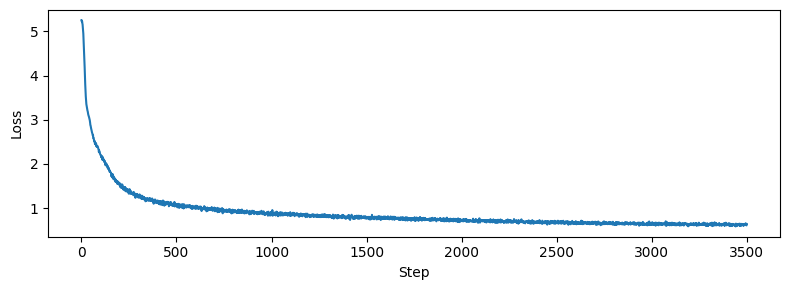

In [6]:
import time
import matplotlib.pyplot as plt

# Flatten all stories into a single token stream with BOS markers as story boundaries
all_tokens = torch.tensor(
    [tok for doc in docs for tok in [BOS] + encode(doc)] + [BOS],
    dtype=torch.long, device=device
)

def get_batch():
    # Sample batch_size random windows of block_size tokens from the stream
    s = torch.randint(0, len(all_tokens) - block_size - 1, (batch_size,), device=device)
    idx = s.unsqueeze(1) + torch.arange(block_size + 1, device=device)
    tokens = all_tokens[idx]
    return tokens[:, :-1], tokens[:, 1:]  # inputs, targets (shifted by 1 for next-token prediction)

# ── Optimizer: AdamW ─────────────────────────────────────────────────────────
num_steps  = 3500   # total training steps
warmup     = 200    # steps to linearly ramp LR up from 0 (stabilises early training)
lr         = 1e-3   # peak learning rate
min_lr     = 1e-4   # 10% of peak — prevents wasted steps at tail

def get_lr(step):
    # Linear warmup then cosine decay to min_lr floor
    if step < warmup:
        return lr * step / warmup
    p = (step - warmup) / (num_steps - warmup)
    return min_lr + (lr - min_lr) * 0.5 * (1 + math.cos(math.pi * p))

opt = torch.optim.AdamW(params, lr=lr, betas=(0.9, 0.95), eps=1e-10, fused=(device.type == 'cuda'))
scaler = torch.amp.GradScaler('cuda')  # scales loss to prevent float16 gradient underflow
losses, t0 = [], time.time()

for step in range(num_steps + 1):
    opt.param_groups[0]['lr'] = get_lr(step)  # update LR each step
    if step % 100 == 0:
        xb, yb = get_batch()
        with torch.no_grad(), torch.amp.autocast('cuda', dtype=torch.float16):
            loss_val = F.cross_entropy(gpt_train(xb).reshape(-1, vocab_size), yb.reshape(-1)).item()
        print(f"step {step:4d}/{num_steps} | loss {loss_val:.4f} | lr {get_lr(step):.2e} | {time.time()-t0:.1f}s")
    if step >= num_steps: break
    opt.zero_grad(set_to_none=True)
    xb, yb = get_batch()
    with torch.amp.autocast('cuda', dtype=torch.float16):
        loss = F.cross_entropy(gpt_train(xb).reshape(-1, vocab_size), yb.reshape(-1))
    scaler.scale(loss).backward()
    scaler.unscale_(opt)
    torch.nn.utils.clip_grad_norm_(params, 1.0)  # prevent loss spikes from large gradients
    scaler.step(opt); scaler.update()
    losses.append(loss.item())

print(f"\nDone in {time.time()-t0:.1f}s")
plt.figure(figsize=(8, 3))
plt.plot(losses); plt.xlabel('Step'); plt.ylabel('Loss'); plt.tight_layout(); plt.show()


## 7. Inference and Text Generation

In [7]:
num_samples    = 5    # number of stories to generate
max_new_tokens = 200  # max tokens per story (stops early if BOS token is predicted)
temperature    = 0.7  # lower = more focused, higher = more random

def generate_sample(max_new_tokens=200, temperature=0.7):
    keys = [[] for _ in range(n_layer)]
    values = [[] for _ in range(n_layer)]
    token_id = BOS
    sample = []
    with torch.no_grad():
        for pos_id in range(max_new_tokens):
            logits = gpt(token_id, min(pos_id, block_size - 1), keys, values)
            probs = F.softmax(logits[:vocab_size] / temperature, dim=-1)
            token_id = torch.multinomial(probs, 1).item()
            if token_id == BOS:
                break
            sample.append(uchars[token_id])
    return ''.join(sample)

t0 = time.time()
for i in range(num_samples):
    print(f"--- sample {i+1} ---\n{generate_sample(max_new_tokens, temperature)}\n")
print(f"Done in {time.time()-t0:.1f}s")


--- sample 1 ---
Once upon a time, there was a big girl named Amy. She lived in the garden with her mommy. They had lots of fun together, feeling happy and surprised.
One day, a little girl named Mia went to the park.

--- sample 2 ---
Once upon a time, there was a little girl named Amy. She lived in a small house with her mommy and dad. Every day she would go on an adventure to her friends.
One day, Sue went to the park with her mo

--- sample 3 ---
One day, a little boy named Tim went to introduce his favorite toy. He was very excited to buy a special toy car instead. His dad would get some! Tim was so happy and thanked his dad for his family.
T

--- sample 4 ---
One day, a little boy named Tim went to the park. He saw a big tree with many colors. Tim was very happy. His dad was happy to see the tree with his friends. From that day on, Tim and the birds were b

--- sample 5 ---
Once upon a time, there was a little boy named Tim. He loved to measure at things. One day, he saw a big bo